There are 0 duplicate values
There are 0 missing values


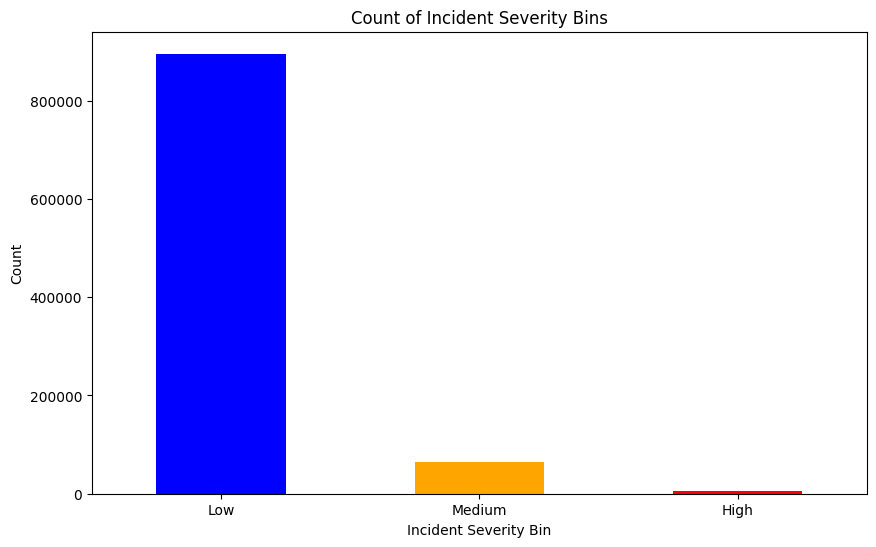

Random Sampling with Replacement bin counts:
 incident_severity_bin
High      63533
Low       63533
Medium    63533
Name: count, dtype: int64


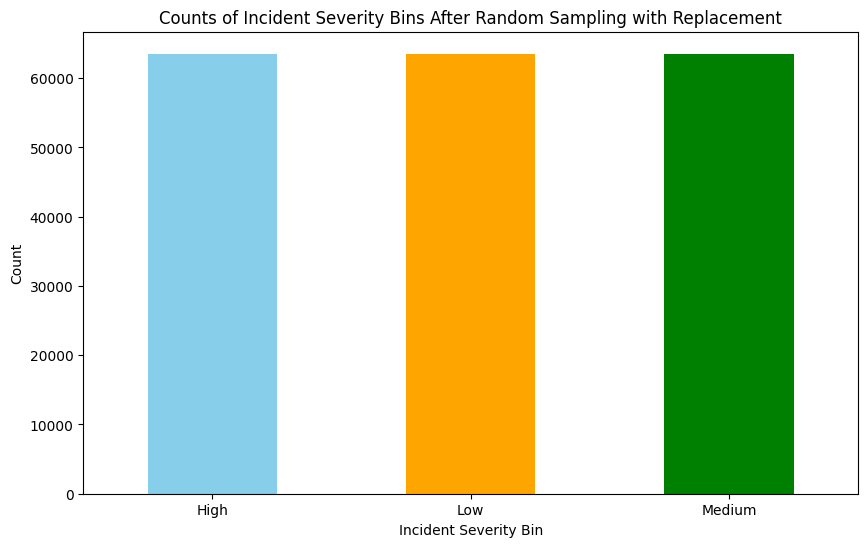

Modeling time: 136.57707738876343 seconds
Best params for Random Forest: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy for Random Forest: 0.94079010727009
Classification report:
              precision    recall  f1-score   support

        High       0.94      1.00      0.97     12607
         Low       0.98      0.93      0.96     12685
      Medium       0.93      0.93      0.93     12828

    accuracy                           0.95     38120
   macro avg       0.95      0.95      0.95     38120
weighted avg       0.95      0.95      0.95     38120

Confusion matrix:
[[12569     0    38]
 [   60 11811   814]
 [  731   213 11884]]


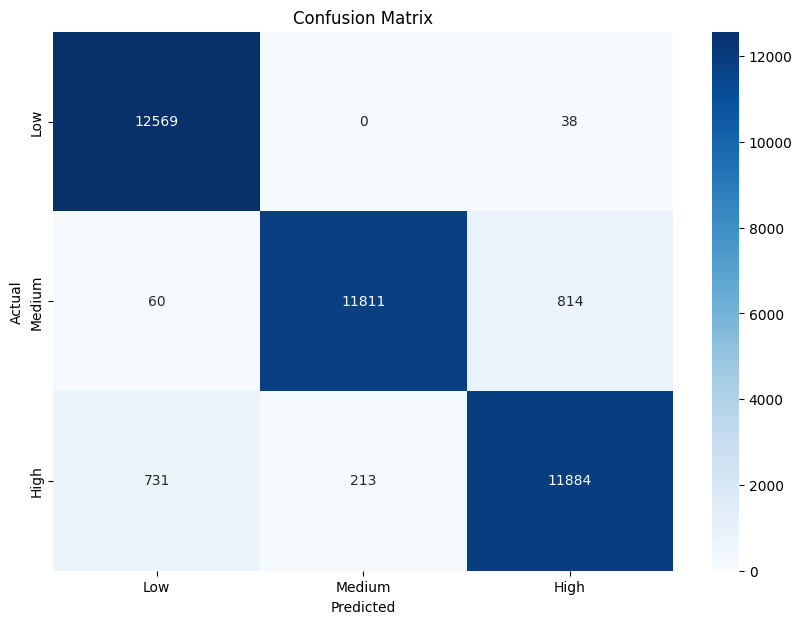

In [3]:
import time
import psycopg2
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Database connection parameters
db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group2',
    'password': 'blockd_2024group2_58'
}

# Create a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# Create an SQLAlchemy engine
engine = create_engine(conn_string)

def load_data(query, engine):
    """
    Load data from database.
    """
    df = pd.read_sql(query, engine)
    return df

# Load data
df_safe_driving = load_data("SELECT * FROM data_lake.safe_driving", engine)

# Ensure 'event_start' and 'event_end' are in datetime format
df_safe_driving['event_start'] = pd.to_datetime(df_safe_driving['event_start'])
df_safe_driving['event_end'] = pd.to_datetime(df_safe_driving['event_end'])
df_safe_driving['date'] = df_safe_driving['event_start'].dt.date

# Remove the 'road_number' column if it exists
if 'road_number' in df_safe_driving.columns:
    df_safe_driving = df_safe_driving.drop('road_number', axis=1)

# Clean 'category' column
df_safe_driving['category'] = df_safe_driving['category'].str.strip()

# Check for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Check for missing values
missing_count = df_safe_driving.isnull().sum().sum()
print('There are', missing_count, 'missing values')

# Remove outliers based on predefined coordinates and duration
outlier_coords = [(51.605330, 4.779188), (51.590760, 4.811617)]
for coord in outlier_coords:
    df_safe_driving = df_safe_driving[~((df_safe_driving['latitude'] == coord[0]) & (df_safe_driving['longitude'] == coord[1]))]
df_safe_driving = df_safe_driving[df_safe_driving['duration_seconds'] <= 500]

# Encode the 'category' column
label_encoder = LabelEncoder()
df_safe_driving['category_encoded'] = label_encoder.fit_transform(df_safe_driving['category'])

# Strip whitespace from the 'incident_severity' column
df_safe_driving['incident_severity'] = df_safe_driving['incident_severity'].str.strip()

def classify_incident_severity(severity):
    low = ['HA1', 'HB1', 'HC1', 'SP1']
    medium = ['HC4', 'HC13', 'HA2', 'HB2', 'HC2', 'HC5', 'HC7', 'HC14', 'HC16', 'SP2', 'SP3']
    high = ['HA3', 'HB3', 'HC3', 'HC9', 'HC11', 'HC12', 'HC15', 'HC17', 'HC18', 'HC19', 'HC20', 'HC21', 'HC6', 'HC8', 'HC10', 'SP4', 'SP5']
    
    if severity in low:
        return 'Low'
    elif severity in medium:
        return 'Medium'
    elif severity in high:
        return 'High'
    else:
        return 'Unknown'

# Apply the classification function
df_safe_driving['incident_severity_bin'] = df_safe_driving['incident_severity'].apply(classify_incident_severity)

# Create a count histogram for the incident_severity_bin
plt.figure(figsize=(10, 6))
df_safe_driving['incident_severity_bin'].value_counts().plot(kind='bar', color=['blue', 'orange', 'red'])
plt.title('Count of Incident Severity Bins')
plt.xlabel('Incident Severity Bin')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Apply Random Sampling with Replacement
sampled_dfs = []
for bin_label, group in df_safe_driving.groupby('incident_severity_bin'):
    sampled_dfs.append(group.sample(n=63533, replace=True, random_state=42))
df_sampled_replacement = pd.concat(sampled_dfs)

# Display the count for each incident severity bin in the resampled data
sampled_replacement_bin_counts = df_sampled_replacement['incident_severity_bin'].value_counts()
print("Random Sampling with Replacement bin counts:\n", sampled_replacement_bin_counts)

# Set the resampled DataFrame to df_safe_driving
df_safe_driving = df_sampled_replacement

# Plot histogram
plt.figure(figsize=(10, 6))
sampled_replacement_bin_counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.xlabel('Incident Severity Bin')
plt.ylabel('Count')
plt.title('Counts of Incident Severity Bins After Random Sampling with Replacement')
plt.xticks(rotation=0)
plt.show()

# Train test split
X = df_safe_driving[['duration_seconds', 'speed_kmh', 'end_speed_kmh', 'maxwaarde', 'category_encoded']]  # Features
y = df_safe_driving['incident_severity_bin']

# Step 2: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Split the train data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Step 4: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)  
X_test_scaled = scaler.transform(X_test)

# Timer start for modeling
start_time = time.time()

# Define and train Random Forest model with class weights
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_rf = grid_search.best_estimator_

# Timer end for modeling
end_time = time.time()
print(f"Modeling time: {end_time - start_time} seconds")

# Evaluate the model
y_pred = best_rf.predict(X_test_scaled)
print(f"Best params for Random Forest: {grid_search.best_params_}")
print(f"Best cross-validation accuracy for Random Forest: {grid_search.best_score_}")
print(f"Classification report:\n{classification_report(y_test, y_pred)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")

# Plot confusion matrix
plt.figure(figsize=(10, 7))
labels = ['Low', 'Medium', 'High']
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
